<p style="text-align: center;"><span style="color: #ff0000;"><strong><span style="font-size: x-large;">
    MODELADO Y VISUALIZACIÓN GRÁFICA</span></strong></span></p>

<p style="text-align: center;"><span style="color: #0000ff;"><strong><span style="font-size: x-large;">PRÁCTICA 1</span></strong></span></p>
<p style="text-align: center;"><span style="color: #0000ff;"><strong><span style="font-size: x-large;">MALLADOS POLIGONALES</span></strong></span></p>

<div style="
    border: 2px solid #1f4fd8;
    padding: 12px;
    border-radius: 8px;
">

<p>
    <span style="color: #0000ff; font-size: large;">
        <strong><a href="#pv">1. Puntos y vectores.</a></strong>
    </span>
</p>

<p>
    <span style="color: #0000ff; font-size: large;">
        <strong><a href="#repr">2. Representaciones gráficas.</a></strong>
    </span>
</p>
    
<p>
    <span style="color: #0000ff; font-size: large;">
        <strong><a href="#pc">3. Propiedades de consistencia.</a></strong>
    </span>
</p>
   
<p style="margin-left: 20px;">
    <span style="color: #0000ff; font-size: medium;">
        <strong><a href="#tri">3.1. Caras no triviales.</a></strong>
    </span>
</p>

<p style="margin-left: 20px;">
    <span style="color: #0000ff; font-size: medium;">
        <strong><a href="#pla">3.2. Caras planas.</a></strong>
    </span>
</p>
    
<p style="margin-left: 20px;">
    <span style="color: #0000ff; font-size: medium;">
        <strong><a href="#sim">3.3. Caras simple-convexas.</a></strong>
    </span>
</p>
    
<p style="margin-left: 20px;">
    <span style="color: #0000ff; font-size: medium;">
        <strong><a href="#norm">3.4. Normales a las caras.</a></strong>
    </span>
</p>
    
<p style="margin-left: 20px;">
    <span style="color: #0000ff; font-size: medium;">
        <strong><a href="#ep">3.5. Fórmula Euler-Poincaré.</a></strong>
    </span>
</p>
    
<p>
    <span style="color: #0000ff; font-size: large;">
        <strong><a href="#sub">4. Subdivisión de mallas poligonales.</a></strong>
    </span>
</p>

**IMPORTANTE:** Para poder hacer uso de todas las funciones que han sido implementadas, debes ejecutar la celda siguiente. Es importante que el fichero Funciones_p1.py se encuentre dentro de la misma carpeta donde esté este notebook

In [1]:
from Funciones_p1 import *

<a name="pv"></a>
## <span style="color:blue">1. Puntos y vectores.</span>

A lo largo de la asignatura, expresaremos vértices, aristas y caras en forma de matrices, en coordenadas homogéneas y por columnas, como suele ser habitual en el contexto del tratamiento de imágenes por ordenador.

En particular: 

* un vértice $P$ de coordenadas cartesianas $(x_P,y_P,z_P)$ se expresará como $P= \left(\begin{array}{c}x_P\\y_P\\z_P\\1\end{array}\right)$.

* una arista $PQ$ se expresará como el vector $U=PQ=(P\;Q)  \left(\begin{array}{r}-1\\1\end{array}\right)$.

* una cara $C=(P_0,P_1,\ldots ,P_n)$ se expresará como una matriz cuyas columnas son los vértices que la componen en coordenadas homogéneas.

Aunque SAGE incluye por defecto muchas de las funciones que necesitamos, como procedimiento habitual optaremos por definirlas por nosotros mismos, lo que en ocasiones facilitará que su comprensión y uso sea más intuitivo e ilustrativo. Las funciones definidas nos permiten realizar operaciones con puntos y vectores, expresadas de forma matricial:

- **vector_puntos(P,Q)**
    - Input: puntos P y Q
    - Output: vector PQ
    
- **producto_escalar(U,V)**
    - Input: vectores U y V
    - Output: escalar U*V = U^t·V   
    
- **producto_vectorial(U,V)**
    - Input: vectores U y V
    - Output: vector producto vectorial U x V  
    
- **modulo(U)**
    - Input: vector U 
    - Output: escalar ||U||=sqrt(U^t·U)

### Ejemplo 1: 

Dado los puntos $P = \left(\begin{array}{c}1\\0\\1\\1\end{array}\right)$
y $Q = \left(\begin{array}{c}2\\1\\-1\\1\end{array}\right)$, vamos a calcular el vector que los une.

In [2]:
P = matrix([[1],[0],[1],[1]])
Q = matrix([[2],[1],[-1],[1]])
PQ = vector_puntos(P,Q)
show('Vector PQ =', PQ)

'Vector PQ =' [ 1]
[ 1]
[-2]
[ 0]

Puedes comprobar que el vector que obtenemos es $Q$-$P$.

In [3]:
PQ == Q-P

True

### Ejemplo 2: 

Dado los vectores $U = \left(\begin{array}{c}3\\0\\4\\0\end{array}\right)$
y $V = \left(\begin{array}{c}2\\4\\-4\\0\end{array}\right)$, vamos a calcular:

a) El módulo de cada vector.

b) El producto escalar de $U$ y $V$.

c) El coseno del ángulo que forman.

d) Un vector unitario perpendicular a $U$ y a $V$.

In [4]:
U = matrix([[3],[0],[4],[0]])
V = matrix([[2],[4],[-4],[0]])

In [5]:
#a)
moduloU = modulo(U)
show('||U|| = ', moduloU)

'||U|| = ' 5

In [6]:
moduloV = modulo(V)
show('||V|| = ', moduloV)

'||V|| = ' 6

In [12]:
#b)
UV = producto_escalar(U,V)
show('U*V = ', UV)

'U*V = ' -10

In [13]:
#c)
coseno = UV/(moduloU*moduloV)
show('coseno = ', coseno, ' = ', coseno.n())

'coseno = ' -1/3 ' = ' -0.333333333333333

In [14]:
#d)
UxV = producto_vectorial(U,V) # vector producto vectorial
moduloUxV = modulo(UxV)       # modulo del vector producto vectorial
show('vector perpendicular unitario = ', UxV/moduloUxV, ' = ', (UxV/moduloUxV).n())

'vector perpendicular unitario = ' [-2/5*sqrt(2)]
[ 1/2*sqrt(2)]
[3/10*sqrt(2)]
[           0] ' = ' [-0.565685424949238]
[ 0.707106781186548]
[ 0.424264068711929]
[ 0.000000000000000]

### <span style="color:red">Ejercicio:</span>

Dado los puntos $P_1 = \left(\begin{array}{c}1\\3\\2\\1\end{array}\right)$,
$P_2 = \left(\begin{array}{c}-2\\5\\-1\\1\end{array}\right)$ y 
$P_3 = \left(\begin{array}{c}-2\\1\\4\\1\end{array}\right)$, 

Calcular un vector perpendicular al plano generado por los vértices $(P_1,P_2,P_3)$.

In [10]:
P1 = matrix([[1], [3], [2], [1]])
P2 = matrix([[-2], [5], [-1], [1]])
P3 = matrix([[-2], [1], [4], [1]])

P1a2 = P2-P1
P1a3 = P3-P1

sol = producto_vectorial(P1a2, P1a3)

show(sol)

[-2]
[15]
[12]
[ 0]

<a name="repr"></a>
## <span style="color:blue">2. Representaciones gráficas.</span>

Los comandos para dibujar implementados en SAGE funcionan con coordenadas cartesianas. Nosotros hemos definimos nuestras propias rutinas para trabajar en coordenadas homogéneas.

- **dibujar_poligono(vertices)**
    - Input: matriz con los vértices del polígono por columnas y en coordenadas homogéneas. Puede recibir otros argumentos como color, transparencia, etc.
    - Output: gráfica del polígono con el borde negro de grosor 1
    
- **dibujar_mallado_poligonal(vertices)**
    - Input: matriz con los vértices del mallado por columnas y en coordenadas homogéneas y matriz de caras. Puede recibir otros argumentos como color, transparencia, etc.
    - Output: gráfica del mallado.

### Ejemplo 1: 

Dados los puntos $P_0=\left(\begin{array}{c}0\\0\\0\\1\end{array}\right)$, $P_1=\left(\begin{array}{c}2\\0\\0\\1\end{array}\right)$, $P_2=\left(\begin{array}{c}1\\2\\0\\1\end{array}\right)$ y $P_3=\left(\begin{array}{c}1\\2\\2\\1\end{array}\right)$:

a) Dibujar el triángulo de vértices $(P_0,P_1,P_2)$ en rojo.

b) Dibujar el triángulo de vértices $(P_0,P_2,P_3)$ en verde.

c) Dibujar ambos triángulos en una misma gráfica.

In [11]:
# Definimos los vértices
P0 = matrix([[0],[0],[1],[1]])
P1 = matrix([[2],[0],[0],[1]])
P2 = matrix([[1],[2],[0],[1]])
P3 = matrix([[1],[2],[2],[1]])

In [12]:
# Construimos la matriz de vértices
vertices = P0.augment(P1).augment(P2).augment(P3)
show('vertices = ', vertices)

'vertices = ' [0 2 1 1]
[0 0 2 2]
[1 0 0 2]
[1 1 1 1]

In [13]:
# Construimos la matriz de vértices del triángulo (P0,P1,P2)
cara1 = [0,1,2]
vertices1 = vertices[:,cara1]
show('P0P1P2 = ', vertices1)

'P0P1P2 = ' [0 2 1]
[0 0 2]
[1 0 0]
[1 1 1]

In [14]:
# Dibujamos PoP1P2 en rojo
dib1 = dibujar_poligono(vertices1, color = 'red')     
show(dib1)

Graphics3d Object

In [15]:
# Construimos la matriz de vértices del triángulo (P0,P2,P3)
cara2 = [0,2,3]
vertices2 = vertices[:,cara2]
show('P0P2P3 = ', vertices2)

'P0P2P3 = ' [0 1 1]
[0 2 2]
[1 0 2]
[1 1 1]

In [16]:
# Dibujamos P0P2P3 en color verde
dib2 = dibujar_poligono(vertices2, color = 'green')     
show(dib2) 

Graphics3d Object

In [17]:
# Dibujamos los dos triángulos juntos
show(dib1 + dib2)

Graphics3d Object

### Ejemplo 2:

Dibujar el siguiente mallado poligonal en color *cyan* dado por su matriz de vértices y caras:

In [19]:
V = matrix([[1,1,1,1,1,1,0,0,0,0,0,0],[0,3,3,2,1,0,0,0,1,2,3,3],[0,1,2,2,1,2,0,2,1,2,2,1],[1,1,1,1,1,1,1,1,1,1,1,1]])
C = matrix([[0,1,2,3,4,5],[6,11,10,9,8,7],[0,6,11,1,-1,-1],[0,5,7,6,-1,-1],[8,7,5,4,-1,-1],[9,8,4,3,-1,-1],[9,3,2,10,-1,-1],[10,2,1,11,-1,-1]])

show('vertices = ', V)
show('caras = ', C)

'vertices = ' [1 1 1 1 1 1 0 0 0 0 0 0]
[0 3 3 2 1 0 0 0 1 2 3 3]
[0 1 2 2 1 2 0 2 1 2 2 1]
[1 1 1 1 1 1 1 1 1 1 1 1]

'caras = ' [ 0  1  2  3  4  5]
[ 6 11 10  9  8  7]
[ 0  6 11  1 -1 -1]
[ 0  5  7  6 -1 -1]
[ 8  7  5  4 -1 -1]
[ 9  8  4  3 -1 -1]
[ 9  3  2 10 -1 -1]
[10  2  1 11 -1 -1]

In [20]:
dib = dibujar_mallado_poligonal(V,C,color = 'cyan', alpha = 0.8)
show(dib)

Graphics3d Object

### <span style="color:red">Ejercicio:</span>

Dados los vértices $Q_0=\left(\begin{array}{c}0\\0\\2\\1\end{array}\right)$, $Q_1=\left(\begin{array}{c}2\\0\\2\\1\end{array}\right)$, $Q_2=\left(\begin{array}{c}1\\2\\2\\1\end{array}\right)$ y $Q_3=\left(\begin{array}{c}0\\2\\2\\1\end{array}\right)$, representar:

a) El polígono $(Q_0,Q_1,Q_2,Q_3)$ en amarillo.

b) El mallado compuesto por los triángulos $(Q_0,Q_1,Q_2)$ y $(Q_0,Q_2,Q_3)$ en verde.

In [23]:
Q0 = matrix([[0], [0], [2], [1]])
Q1 = matrix([[2], [0], [2], [1]])
Q2 = matrix([[1], [2], [2], [1]])
Q3 = matrix([[0], [2], [2], [1]])

m = Q0.augment(Q1).augment(Q2).augment(Q3)

pv = matrix([[0,2,1,0],[0,0,2,2],[2,2,2,2],[1,1,1,1]])
pa = matrix([[0,1,2], [0,2,3]])

dib1 = dibujar_poligono(m, color = 'green')
dib2 = dibujar_mallado_poligonal(pv,pa,color = 'cyan', alpha = 0.8)

show(dib1)
show(dib2)

Graphics3d Object

Graphics3d Object

<a name="pc"></a>
## <span style="color:blue">3. Propiedades de consistencia.</span>

<a name="tri"></a>
### <span style="color:blue">3.1. Caras no triviales.</span>

Para comprobar que tres vértices $P_0,P_1,P_2$ no están alineados:

- comprobamos que el módulo del vector producto vectorial $P_0P_1 \times P_0P_2$ es no nulo.
 
Para comprobar que un polígono $(P_0,P_1,P_2,P_3,..., P_n)$ no es trivial: 

- comprobamos que hay al menos 3 vértices no alineados, es decir, que hay una secuencia que mantiene el orden cíclico de los vértices $(P_0,P_1,P_2,P_3,..., P_n)$ para la cuál $P_0,P_1,P_n$ no están alineados.

### Ejemplo 1:

Vamos a comprobar que el polígono definido por la siguiente matriz de vértices es no trivial. 

In [24]:
Vertices = matrix([[1,1,1,1,1],[3,6,3,3,0],[1,2,3,3,0],[1,1,1,1,1]])
show('Vértices = ', Vertices)

'Vértices = ' [1 1 1 1 1]
[3 6 3 3 0]
[1 2 3 3 0]
[1 1 1 1 1]

Probamos inicialmente con la ordenación dada, $(P_0,P_1,P_2,P_3,P_4)$, es decir, vemos si $P_0$, $P_1$ y $P_4$ no están alineados:

In [25]:
cara = [0,1,2,3,4]
P0P1 = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[1]])
P0Pn = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[-1]])

N = producto_vectorial(P0P1,P0Pn)
show('Vector normal P0P1Pn = ', N)
show('Módulo = ', modulo(N))

'Vector normal P0P1Pn = ' [0]
[0]
[0]
[0]

'Módulo = ' 0

Los vértices $P_0,P_1,P_4$ están alineados, luego reordenamos los vértices de la cara $(P_1,P_2,P_3,P_4,P_0)$. Probamos ahora si lo vértices $P_1,P_2,P_0$ están alineados o no:

In [26]:
cara2 = [cara[i+1] for i in range(0,Vertices.ncols()-1)]
cara2.append(cara[0])
print('nueva ordenación de la cara:',cara2)

nueva ordenación de la cara: [1, 2, 3, 4, 0]


In [27]:
P0P1 = vector_puntos(Vertices[:,cara2[0]],Vertices[:,cara2[1]])
P0Pn = vector_puntos(Vertices[:,cara2[0]],Vertices[:,cara2[-1]])

N = producto_vectorial(P0P1,P0Pn)
show('Vector normal P0P1Pn = ',N)
show('Módulo = ',modulo(N))

'Vector normal P0P1Pn = ' [6]
[0]
[0]
[0]

'Módulo = ' 6

Los vértices $P_1,P_2,P_0$ no están alineados. Luego, demostramos que la cara es no trivial. Esta cara se representará con la nueva secuencia de vértices $(P_1,P_2,P_3,P_4,P_0)$.

### Ejemplo 2:

Dado el mallado poligonal siguiente, vamos a comprobar si la cara correspondiente a la cuarta fila de la matriz de caras *C* es no trivial:

In [28]:
Vertices = matrix([[1,1,1,1,1,1,0,0,0,0,0,0],[0,3,3,2,1,0,0,0,1,2,3,3],[0,1,2,2,1,2,0,2,1,2,2,1],[1,1,1,1,1,1,1,1,1,1,1,1]])
Caras = matrix([[0,1,2,3,4,5],[6,11,10,9,8,7],[0,6,11,1,-1,-1],[0,5,7,6,-1,-1],[8,7,5,4,-1,-1],[9,8,4,3,-1,-1],[9,3,2,10,-1,-1],[10,2,1,11,-1,-1]])

show('Vertices = ', Vertices)
show('Caras = ', Caras)

'Vertices = ' [1 1 1 1 1 1 0 0 0 0 0 0]
[0 3 3 2 1 0 0 0 1 2 3 3]
[0 1 2 2 1 2 0 2 1 2 2 1]
[1 1 1 1 1 1 1 1 1 1 1 1]

'Caras = ' [ 0  1  2  3  4  5]
[ 6 11 10  9  8  7]
[ 0  6 11  1 -1 -1]
[ 0  5  7  6 -1 -1]
[ 8  7  5  4 -1 -1]
[ 9  8  4  3 -1 -1]
[ 9  3  2 10 -1 -1]
[10  2  1 11 -1 -1]

In [29]:
cara = [n for n in Caras[3] if n>-1] #la cuarta fila se corresponde con la fila de índice 3
print('cara = ', cara)

P0P1 = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[1]])
P0Pn = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[-1]])

N = producto_vectorial(P0P1,P0Pn)
show('Vector normal P0P1Pn = ',N)
show('Módulo = ',modulo(N))

cara =  [0, 5, 7, 6]


'Vector normal P0P1Pn = ' [ 0]
[-2]
[ 0]
[ 0]

'Módulo = ' 2

Los vértices $P_0,P_5,P_6$ no están alineados. Luego, la cara correspondiente a la cuarta fila de la mariz no es trivial.

### <span style="color:red">Ejercicio:</span>

Comprueba si la cara correspondiente a la segunda fila del mallado poligono anterior es no trivial.

In [30]:
Vertices = matrix([[1,1,1,1,1,1,0,0,0,0,0,0],[0,3,3,2,1,0,0,0,1,2,3,3],[0,1,2,2,1,2,0,2,1,2,2,1],[1,1,1,1,1,1,1,1,1,1,1,1]])
Caras = matrix([[0,1,2,3,4,5],[6,11,10,9,8,7],[0,6,11,1,-1,-1],[0,5,7,6,-1,-1],[8,7,5,4,-1,-1],[9,8,4,3,-1,-1],[9,3,2,10,-1,-1],[10,2,1,11,-1,-1]])

show('Vertices = ', Vertices)
show('Caras = ', Caras)

'Vertices = ' [1 1 1 1 1 1 0 0 0 0 0 0]
[0 3 3 2 1 0 0 0 1 2 3 3]
[0 1 2 2 1 2 0 2 1 2 2 1]
[1 1 1 1 1 1 1 1 1 1 1 1]

'Caras = ' [ 0  1  2  3  4  5]
[ 6 11 10  9  8  7]
[ 0  6 11  1 -1 -1]
[ 0  5  7  6 -1 -1]
[ 8  7  5  4 -1 -1]
[ 9  8  4  3 -1 -1]
[ 9  3  2 10 -1 -1]
[10  2  1 11 -1 -1]

In [31]:
cara = [n for n in Caras[1] if n>-1] #la cuarta fila se corresponde con la fila de índice 3
print('cara = ', cara)

P0P1 = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[1]])
P0Pn = vector_puntos(Vertices[:,cara[0]],Vertices[:,cara[-1]])

N = producto_vectorial(P0P1,P0Pn)
show('Vector normal P0P1Pn = ',N)
show('Módulo = ',modulo(N))

cara =  [6, 11, 10, 9, 8, 7]


'Vector normal P0P1Pn = ' [6]
[0]
[0]
[0]

'Módulo = ' 6

<a name="pla"></a>
### <span style="color:blue">3.2. Caras planas.</span>

Una cara no trivial $(P_0, ..., P_n)$ (considerando no alineados $P_0, P_1, P_n$) es plana si todos los vértices pertenecen a un mismo plano. Los pasos a seguir son: 

- calculamos la ecuación del plano generado por $P_0, P_1, P_n$, es decir, plano de vector normal $N = P_0P_1 \times P_0P_n$ pasando por $P_0$ (por ejemplo).

- para el recto de vértices $P_i$, comprobamos si pertenecen al plano anterior. Si todos pertenecen, la cara es plana. 

*Nota: La ordenación de los vértices de la cara viene dada por la comprobación de la no trivialidad*

La ecuación del plano de vector normal $N$ que contiene a $P_0$ puede verse como

$$(N_x \quad N_y \quad N_z \quad -N*P_0)·\left(\begin{array}{c}x\\y\\z\\1\end{array}\right)=0, \quad [1]$$

o bien como el producto escalar

$$N * P_0X = 0, \quad X = \left(\begin{array}{c}x\\y\\z\\1\end{array}\right), \quad [2]$$

*Nota: Ambas ecuaciones son equivalentes*

### Ejemplo 1:

Vamos a probar si el polígono definido por los siguientes vértices es plano: $P_0=\left(\begin{array}{c}1\\2\\3\\1\end{array}\right)$, $P_1=\left(\begin{array}{c}1\\0\\1\\1\end{array}\right)$, $P_2=\left(\begin{array}{c}2\\3\\3\\1\end{array}\right)$ y $P_3=\left(\begin{array}{c}2\\3\\4\\1\end{array}\right)$

In [35]:
vertices = matrix([[1,1,2,2],[2,0,3,3],[3,1,3,4],[1,1,1,1]])
show('Vértices = ', vertices)

'Vértices = ' [1 1 2 2]
[2 0 3 3]
[3 1 3 4]
[1 1 1 1]

Definimos los puntos por separado también, por comodidad:

In [36]:
P0 = vertices[:,0]
P1 = vertices[:,1]
P2 = vertices[:,2]
P3 = vertices[:,3]

**Paso 1:** Calculamos el vector normal al plano generado por los puntos $P_0,P_1,P_3$, es decir, $N = P_0P_1 \times P_0P_3$

In [37]:
U = vector_puntos(P0,P1)         
V = vector_puntos(P0,P3)        
N = producto_vectorial(U,V) 
show('N = ', N)

'N = ' [ 0]
[-2]
[ 2]
[ 0]

**Paso 2:** Comprobamos si $P_2$ pertenece al plano usando la fórmula [1] del plano

In [38]:
coef_plano = matrix([N[0,0], N[1,0], N[2,0], -producto_escalar(P0,N)])  
show(coef_plano)

[ 0 -2  2 -2]

La ecuación del plano es: $\left(\begin{array}{cccc}0 & -2 & 2 & -2\end{array}\right) \left(\begin{array}{c}x\\y\\z\\1\end{array}\right)=0 \rightarrow -2y+2z=2$.

In [38]:
coef_plano*P2

[-2]

**Conclusión:** Como dicho valor es distinto de cero, el vértice $P_2$ no está en el plano y por tanto, la cara $(P_0,P_1,P_2,P_3)$ no es plana.

**Paso 2:** Comprobamos si $P_2$ pertenece al plano usando la fórmula [2] del plano

In [39]:
h2 = producto_escalar(N, vector_puntos(P0,P2))
show('h2 = ', h2)

'h2 = ' -2

**Conclusión:** Como dicho valor es distinto de cero, el vértice $P_2$ no está en el plano y por tanto, la cara $(P_0,P_1,P_2,P_3)$ no es plana.

Vamos a representarla para comprobarlo gráficamente:

In [40]:
dibujar_poligono(vertices, color = 'orange')     

Graphics3d Object

### <span style="color:red">Ejercicio:</span>

Comprueba si las siguientes caras son planas o no:

Cara 1: $(P_0,P_1,P_2,P_3)$, donde $P_0=\left(\begin{array}{c}1\\2\\3\\1\end{array}\right)$, $P_1=\left(\begin{array}{c}1\\0\\1\\1\end{array}\right)$, $P_2=\left(\begin{array}{c}3\\5\\4\\1\end{array}\right)$ y $P_3=\left(\begin{array}{c}2\\3\\3\\1\end{array}\right)$.

Cara 2: $(P_0,P_1,P_2,P_3)$, donde $P_0=\left(\begin{array}{c}1\\0\\0\\1\end{array}\right)$, $P_1=\left(\begin{array}{c}0\\1\\0\\1\end{array}\right)$, $P_2=\left(\begin{array}{c}0\\1\\1\\1\end{array}\right)$ y $P_3=\left(\begin{array}{c}0\\0\\1\\1\end{array}\right)$.

In [33]:
def es_plana(P0, P1, P2, P3):
    P0a3 = P3 - P0
    P0a2 = P2 - P0
    P0a1 = P1 - P0

    triangulo = producto_vectorial(P0a3, P0a2)
    proyeccion = producto_escalar(triangulo, P0a1)

    if proyeccion != 0:
        return False
    else:
        return True

In [34]:
P10 = matrix([[1], [2], [3], [1]])
P11 = matrix([[1], [0], [1], [1]])
P12 = matrix([[3], [5], [4], [1]])
P13 = matrix([[2], [3], [3], [1]])

print(es_plana(P10, P11, P12, P13))

P20 = matrix([[1], [0], [0], [1]])
P21 = matrix([[0], [1], [0], [1]])
P22 = matrix([[0], [1], [1], [1]])
P23 = matrix([[0], [0], [1], [1]])

print(es_plana(P20, P21, P22, P23))

True
False


### <span style="color:red">Ejercicio:</span>

Otra manera de ver si una cara es plana, es triangulando la cara y comprobando que todas las normales a cada uno de los triángulos tienen la misma dirección y sentido (es decir, el ángulo que forman es $0$, o equivalentemente, su coseno es $1$). Implementa un método que detecte si una cara es plana usando esta idea y compruébalo con los datos del ejercicio anterior.

*Nota: Un polígono de vértices $(P_0,P_1,P_2,P_3,...)$ está formado por los triángulos  $(P_0,P_1,P_2)$, $(P_0,P_2,P_3)$, $(P_0,P_3,P_4)$, ... Si el polígono tiene $n$ vértices, se decompone en $n-2$ triángulos de la forma anterior.*

In [39]:
def polla(matriz):
    res = True
    normales = list()
    for i in range(len(matriz[:,0]) - 2):
        P0 = matriz[0,:2]
        Pi1 = matriz[i+1,:2]
        Pi2 = matriz[i+2,:2]
        normales.append(producto_vectorial(Pi1-P0, Pi2-P0)/modulo(producto_vectorial(Pi1-P0, Pi2-P0)))
    for i in range(len(normales) - 1):
        if producto_escalar(normales[0], normales[i+1]) != 1:
            res = False
    return res

<a name="sim"></a>
### <span style="color:blue">3.3. Caras simple-convexas.</span>

Una cara $(P_0,P_1,...,P_n)$ compuesta por vértices no repetidos es simple-convexa si sus aristas no consecutivas no se cortan y encierran un área convexa.

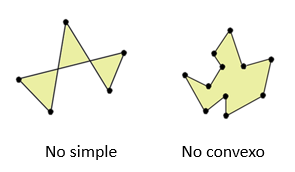

Los pasos a seguir son: 

- calculamos el vector normal al plano generado por $P_0, P_1, P_n$, es decir, $N = P_0P_1 \times P_0P_n$.

- para cada arista $P_i P_{i+1}$: 
    - calculamos el plano perpendicular a la cara pasando por dicha arista, cuyo vector normal es $W = N \times P_i P_{i+1}$
    - para el resto de vértices $P_j$, comprobamos el signo al sustituir en la ecuación del plano anterior.
    - si todos los vértices producen el mismo signo, el polígono es simple-convexo. En caso contrario, no es simple-convexo.

### Ejemplo 1:

Vamos a probar si la cara no trivial y plana $(P_0,P_1,P_2,P_3,P_4,P_5)$ es simple-convexa, donde los vértices vienen dados en la siguiente matriz:

In [53]:
vertices = matrix([[1,1,1,1,1,1],[0,3,3,2,1,0],[0,0,1,1,2,2],[1,1,1,1,1,1]])
show('vertices = ', vertices)

'vertices = ' [1 1 1 1 1 1]
[0 3 3 2 1 0]
[0 0 1 1 2 2]
[1 1 1 1 1 1]

**Paso 1:** Como sabemos que la cara es plana, calcular el vector normal a ella $N = P_0P_1 \times P_0P_n$

In [54]:
P0 = vertices[:,0]
P1 = vertices[:,1]
Pn = vertices[:,-1]
    
U = vector_puntos(P0,P1)         
V = vector_puntos(P0,Pn)         
N = producto_vectorial(U,V)

**Paso 2:** Arista $P_0 P_{1}$ 

In [55]:
P0 = vertices[:,0]
P1 = vertices[:,1]
P0P1 = vector_puntos(P0,P1)
W0 = producto_vectorial(N,P0P1) 

In [56]:
# ecuación [1]
M = matrix([W0[0,0], W0[1,0], W0[2,0], -producto_escalar(P0,W0)])
comprobacion1 = [(matrix(M)*vertices[:,j])[0,0] for j in range(vertices.ncols())]
show(comprobacion1)

[0, 0, 18, 18, 36, 36]

In [57]:
# ecuación [2]
comprobacion2 = [producto_escalar(W0,vector_puntos(P0,vertices[:,j])) for j in range(vertices.ncols())] 
show(comprobacion2)

[0, 0, 18, 18, 36, 36]

Observamos que: 

- los vértices $P_0$ y $P_1$ pertenecen al plano ya que al sustituirlos en la ecuación del plano obtenemos el valor $0$ como resultado; 
- el resto de vértices $P_j$ están en el mismo semiespacio ya que todos dan un valor positivo.

**Paso 3:** Arista $P_1 P_2$ 

In [58]:
P2 = vertices[:,2]
P1P2 = vector_puntos(P1,P2)
W1 = producto_vectorial(N,P1P2) 

In [59]:
# ecuación [1]
M = matrix([W1[0,0], W1[1,0], W1[2,0], -producto_escalar(P1,W1)])
comprobacion1 = [(matrix(M)*vertices[:,j])[0,0] for j in range(vertices.ncols())]
show(comprobacion1)

[18, 0, 0, 6, 12, 18]

In [60]:
# ecuación [2]
comprobacion2 = [producto_escalar(W1,vector_puntos(P1,vertices[:,j])) for j in range(vertices.ncols())] 
show(comprobacion2)

[18, 0, 0, 6, 12, 18]

Observamos que: 

- los vértices $P_1$ y $P_2$ pertenecen al plano ya que al sustituirlos en la ecuación del plano obtenemos el valor $0$ como resultado; 
- el resto de vértices $P_j$ están en el mismo semiespacio ya que todos dan un valor positivo.

**Paso 4:** Arista $P_2 P_3$ 

In [61]:
P3 = vertices[:,3]
P2P3 = vector_puntos(P2,P3)
W2 = producto_vectorial(N,P2P3) 

In [62]:
# ecuación [1]
M = matrix([W2[0,0], W2[1,0], W2[2,0], -producto_escalar(P2,W2)])
comprobacion1 = [(matrix(M)*vertices[:,j])[0,0] for j in range(vertices.ncols())]
show(comprobacion1)

[6, 6, 0, 0, -6, -6]

In [63]:
# ecuación [2]
comprobacion2 = [producto_escalar(W2,vector_puntos(P2,vertices[:,j])) for j in range(vertices.ncols())] 
show(comprobacion2)

[6, 6, 0, 0, -6, -6]

Observamos que: 

- los vértices $P_2$ y $P_3$ pertenecen al plano ya que al sustituirlos en la ecuación del plano obtenemos el valor $0$ como resultado; 
- los vértices $P_0, P_1$ están en un semiespacio (valor positivo en la ecuación del plano) y los vértices $P_4, P_5$ están en el otro semiespacio (valor negativo en la ecuación del plano).

**Conclusión:** La cara no es simple-convexa.

Representamos gráficamente la cara:

In [64]:
dibujar_poligono(vertices,color = 'green', alpha = 0.5)

Graphics3d Object

### <span style="color:red">Ejercicio:</span>


Divide la cara anterior en dos caras que si sean simple-convexas. Compruébalo. 

<a name="norm"></a>
### <span style="color:blue">3.4. Orientación de las normales.</span>

Los vértices que determinan las caras del mallado deben estar ordenados de forma que la normal a todas las caras apunten siempre en el mismo sentido. Una forma eficiente de comprobar que todas las normales apuntan en el mismo sentido consiste en verificar, por cada arista $(i,j)$,  si ésta aparece exactamente dos veces: una en orden directo $(i,j)$ y otra en orden inverso $(j,i)$.

Para ello, usamos la siguiente función:

- **matriz_M(vertices, caras)** 
    - Input: matriz con los vértices del mallado por columnas y en coordenadas homogéneas y matriz de caras.
    - Output: matriz $M$ tal que $M(i,j)$ indica el número de veces que se recorre la arista $(v_i,v_j)$:

Por tanto, si cada arista se recorre en ambos sentidos, entonces la matriz $M$ debe ser simétrica.

### Ejemplo:

Vamos a comprobar si todas las normales apuntan al mismo sentido en el siguiente mallado:

In [67]:
vertices = matrix([[0,1,1,0,0,1,1,0],[0,0,1,1,0,0,1,1],[1,1,1,1,0,0,0,0],[1,1,1,1,1,1,1,1]])
caras = matrix([[2,6,7,3],[6,7,4,5],[5,4,0,1],[1,0,3,2],[0,4,7,3],[1,2,6,5]])

In [68]:
M = matriz_M(vertices, caras)
show('M = ', M)

'M = ' [0 1 0 1 1 0 0 0]
[1 0 1 0 0 1 0 0]
[0 1 0 0 0 0 2 0]
[1 0 2 0 0 0 0 0]
[1 0 0 0 0 1 0 1]
[0 1 0 0 1 0 1 0]
[0 0 0 0 0 1 0 2]
[0 0 0 2 1 0 0 0]

Observa que, por ejemplo, $M(2,6) = 2$ y $M(6,2) = 0$: 
- la arista que une los vértices $P_2$ y $P_6$ se recorre dos veces de $P_2$ y $P_6$
- no se recorre la arista en sentido inverso, es decir, de $P_6$ y $P_2$. 

Eso significa que el mallado tiene caras con normales apuntando a distintos lados. Podemos corroborar esto simplemente comprobando que la matriz $M$ no es simétrica.

In [69]:
M.is_symmetric() 

False

Para ver cuáles son las aristas que se recorren más de una vez, aplicamos la siguiente función:

- **aristas_recorrido_repetido(M)**
    - Input: Matriz $M$
    - Ouput: Lista con las aristas $(P_i,P_j)$ que se recorren más de una vez

In [58]:
show(aristas_recorrido_repetido(M))

[(2, 3), (2, 6), (3, 7), (6, 7)]

Las aristas que se recorren más de una vez son las que unen los pares de vértices: $P_2$ y $P_3$; $P_2$ y $P_6$; $P_3$ y $P_7$; $P_6$ y $P_7$. Vemos a qué cara corresponden:

In [59]:
show('Caras = ', caras)

'Caras = ' [2 6 7 3]
[6 7 4 5]
[5 4 0 1]
[1 0 3 2]
[0 4 7 3]
[1 2 6 5]

La cara mal orientada es $[2,6,7,3]$. Cambiamos la orientación y comprobamos que ahora sí están todas bien orientadas.

In [60]:
caras2 = matrix([[2,3,7,6],[6,7,4,5],[5,4,0,1],[1,0,3,2],[0,4,7,3],[1,2,6,5]])

In [61]:
M = matriz_M(vertices, caras2)
M.is_symmetric()

True

**Conclusión:** Al ser la salida True, ya podemos asegurar que todas las caras están bien orientadas.

<a name="ep"></a>
### <span style="color:blue">3.5. Fórmula de Euler-Poicaré.</span>

Otra propiedad que ha de verificar un mallado poligonal consistente de un modelo 3D *cerrado* es la **Fórmula de Euler-Poincaré**, que relaciona el número $V$ de vértices, $A$ de aristas, $C$ de caras y $g$ de cavidades (o género) del modelo:

$$V-A+C=2(1-g)$$

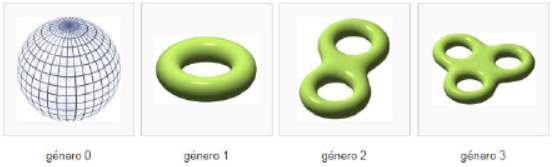

Se ha definido la siguiente función: 

- **num_v_a_c(vertices,caras)** 
    - Input: matriz con los vértices del mallado por columnas y en coordenadas homogéneas y matriz de caras.
    - Output: número de vértices, aristas y caras del mismo.

Con el resultado de esta función y suponiendo que conocemos el género del modelo, podemos comprobar que se verifique la fórmula de euler. Veamos un ejemplo.

### Ejemplo 1:

Vamos a comprobar que el mallado del ejercicio anterior tiene género $0$.

In [62]:
vertices = matrix([[0,1,1,0,0,1,1,0],[0,0,1,1,0,0,1,1],[1,1,1,1,0,0,0,0],[1,1,1,1,1,1,1,1]])
caras2 = matrix([[2,3,7,6],[6,7,4,5],[5,4,0,1],[1,0,3,2],[0,4,7,3],[1,2,6,5]])

In [63]:
[num_v,num_a,num_c] = num_v_a_c(vertices,caras2)
g = 0

In [64]:
num_v - num_a + num_c == 2*(1-g)

True

Como el resultado es True, hemos comprobado que se verifica la fórmula de euler para $g=0$. Por tanto, nuestro modelo no tiene ningún 'agujero'.

Podemos probar con modelos más complicados, extraidos de ficheros con extension .obj. Para ello, usamos la función:
- **leer_objeto_obj(path)**
    - Input: ruta donde se encuente el fichero .obj
    - Output: matriz con los vértices del mallado por columnas y en coordenadas homogéneas y matriz de caras.

### <span style="color:red">Ejercicio:</span>

Considera el archivo *rueda_carro_manifold.obj*. Sabiendo que se cumple la fórmula de Euler-Poincaré, determinamos el género.

In [70]:
vertices, caras = leer_objeto_obj('Ficheros obj/rueda_carro_manifold.obj')
dibujar_mallado_poligonal(vertices, caras)

FileNotFoundError: [Errno 2] No such file or directory: 'Ficheros obj/rueda_carro_manifold.obj'

In [71]:
[num_v,num_a,num_c] = num_v_a_c(vertices,caras)
g = (2 - num_v + num_a - num_c)/2
show('género = ', g)

'género = ' 0.0

<a name="sub"></a>
## <span style="color:blue">4. Subdivisión de mallas poligonales: método Catmull-Clark.</span>

Las funciones que vamos a usar para calcular los *puntos-cara*, *puntos-arista* y coordenadas de los *vértices modificados* son: 

- **baricentro(vertices)** 
    - Input: matriz con las coordenadas de los vértices del polígono por columna y en coordenadas homogéneas
    - Output: coordenadas del baricentro 

- **caras_arista(i,j,C)** 
    - Input: índices $i$ y $j$ de la arista $P_i P_j$ y matriz de caras $C$
    - Output: lista con los índices de las caras adyacentes a la arista $P_i P_j$
    
- **caras_vertice(i,C)** 
    - Input: índice $i$ del vértice $P_i$ y matriz de caras $C$
    - Output: lista con los índices de las caras adyacentes al vértice $P_i$
    
- **vertices_adyacentes(i,C)**  
    - Input: índice $i$ del vértice $P_i$ y matriz de caras $C$
    - Output: lista con los índices de las vértices adyacentes al vértice $P_i$

### Ejemplo 1:

Considera el mallado poligonal dado por las siguientes matrices de vértices y caras:

In [74]:
V = matrix(QQ,[[-1,-1,1,1],[-1,1,1,1],[-1,-1,-1,1],[-1,1,-1,1],[1,-1,1,1],[1,1,1,1],[1,-1,-1,1],[1,1,-1,1]]).transpose()
show('Vértices = ', V)
C = matrix([[0,1,3,2],[4,5,7,6],[0,1,5,4],[2,3,7,6],[0,2,6,4],[1,3,7,5]])
show('Caras = ', C)

'Vértices = ' [-1 -1 -1 -1  1  1  1  1]
[-1  1 -1  1 -1  1 -1  1]
[ 1  1 -1 -1  1  1 -1 -1]
[ 1  1  1  1  1  1  1  1]

'Caras = ' [0 1 3 2]
[4 5 7 6]
[0 1 5 4]
[2 3 7 6]
[0 2 6 4]
[1 3 7 5]

### Puntos-cara: 
Calcular el *punto-cara* asociado a la tercera cara del mallado (índice 2).

In [75]:
cara2 = [n for n in C[2] if n>-1] 
show('cara2 = ', cara2)

'cara2 = ' [0, 1, 5, 4]

In [76]:
vertices_cara2 = V[:,cara2]
show('vértices cara2 = ', vertices_cara2)

'vértices cara2 = ' [-1 -1  1  1]
[-1  1  1 -1]
[ 1  1  1  1]
[ 1  1  1  1]

In [77]:
pc2 = baricentro(vertices_cara2)
show('punto-cara2 = ', pc2)

'punto-cara2 = ' [0]
[0]
[1]
[1]

### Puntos-arista: 

Calcular el *punto-arista* asociado a la arista que une los vértices $P_0$ y $P_1$.

En primer lugar, debemos ver las caras que comparten dicha arista:

In [78]:
caras_arista01 = caras_arista(0,1,C)
show('P0P1 compartida por las caras ', caras_arista01)

'P0P1 compartida por las caras ' [0, 2]

Calculamos el punto-cara asociado a la cara 0:

In [79]:
cara0 = [n for n in C[0] if n>-1] 
vertices_cara0 = V[:,cara0]
pc0 = baricentro(vertices_cara0)
show('punto-cara0 = ', pc0)

'punto-cara0 = ' [-1]
[ 0]
[ 0]
[ 1]

Para calcular el punto-arista, debemos calcular el baricentro del polígono de vértices $P_0$, $P_1$, $pc0$ y $pc2$:

In [80]:
P0 = V[:,0]
P1 = V[:,1]
pa_01 = baricentro(P0.augment(P1).augment(pc0).augment(pc2))
show('punto-arista P0P1 = ',  pa_01)

'punto-arista P0P1 = ' [-3/4]
[   0]
[ 3/4]
[   1]

### Vértices modificados: 

Calcular las nuevas coordenadas del vértice $P_0$.

En primer lugar, debemos ver a qué caras pertenece el vértice $P_0$:

In [81]:
caras_vertice0 = caras_vertice(0,C)
show('P0 pertenece a las caras ', caras_vertice0)

'P0 pertenece a las caras ' [0, 2, 4]

Calculamos el punto-cara asociado a la cara 4 (el que nos falta):

In [82]:
cara4 = [n for n in C[4] if n>-1] 
vertices_cara4 = V[:,cara4]
pc4 = baricentro(vertices_cara4)
show('punto-cara4 = ', pc4)

'punto-cara4 = ' [ 0]
[-1]
[ 0]
[ 1]

Luego, ya podemos calcular $m_1$ = baricentro del polígono determinado por los puntos-cara de las caras a las que pertenece $P_0$

In [83]:
m1 = baricentro(pc0.augment(pc2).augment(pc4))
show('m1 = ', m1)

'm1 = ' [-1/3]
[-1/3]
[ 1/3]
[   1]

Ahora tenemos que ver las aristas que contienen el vértice $P_0$:

In [77]:
vertices_adyacentes0 = vertices_adyacentes(0, C)
show('Vértices adyacentes a P0 son = ', vertices_adyacentes0)

'Vértices adyacentes a P0 son = ' [1, 2, 4]

Luego, las aristas que contienen a $P_0$ son $P_0P_1$, $P_0P_2$ y $P_0P_4$. Calculamos sus puntos medios:

In [78]:
pm01 = (V[:,0] + V[:,1])/2
pm02 = (V[:,0] + V[:,2])/2
pm04 = (V[:,0] + V[:,4])/2

Calculamos $m_2$ = baricentro del polígono determinado por los puntos medios:

In [79]:
m2 = baricentro(pm01.augment(pm02).augment(pm04))
show('m2 = ', m2)

'm2 = ' [-2/3]
[-2/3]
[ 2/3]
[   1]

Finalmente, el vértice $P_0$ modificado quedaría como:

$$P'_0 = \frac{m_1 + 2 m_2 + (n-3) P_0}{n}$$

siendo, en este caso, $n=3$. Por tanto: 

$$P'_0 = \frac{m_1 + 2 m_2}{3}$$

In [80]:
P0mod = (m1 + 2*m2)/3
show('P0 modificado = ', P0mod)

'P0 modificado = ' [-5/9]
[-5/9]
[ 5/9]
[   1]

## Función catmull_clark_it:

Finalmente, se ha implementado una función para aplicar el argoritmo:   que nos permite obtener las nuevas matrices de vértices y caras del mallado al realizar tantas iteraciones del método como le indiquemos en el argumento de la función.

- **catmull_clark_it(vertices,caras,it)**
    - Input: matriz con los vértices del mallado por columnas y en coordenadas homogéneas y matriz de caras. it = número de iteraciones del algoritmo
    - Output: vértices y caras del mallado resultante de aplicar Catmull Clark it veces.

In [81]:
V1,C1 = catmull_clark_it(V,C,1)
dibujar_mallado_poligonal(V1,C1,color = 'green')

Graphics3d Object

In [82]:
V2,C2 = catmull_clark_it(V1,C1,1)
dibujar_mallado_poligonal(V2,C2,color = 'green')

Graphics3d Object

In [83]:
V3,C3 = catmull_clark_it(V2,C2,1)
dibujar_mallado_poligonal(V3,C3,color = 'green')

Graphics3d Object

In [84]:
V4,C4 = catmull_clark_it(V3,C3,1)
dibujar_mallado_poligonal(V4,C4,color = 'green')

Graphics3d Object

In [85]:
#Directamente 
V4,C4 = catmull_clark_it(V,C,4)
dibujar_mallado_poligonal(V4,C4,color = 'green')

Graphics3d Object

### <span style="color:red">Ejercicio:</span>

Considera el archivo rueda_carro_manifold.obj. 

a) Calcula el punto-cara correspondiente a la cara 100 del mallado así como las coordenadas modificadas del vértices 80.

a) Aplica el algoritmo Catmull-Clark 3 veces.

b) Calcula el número de vértices, aristas y caras del mallado poligonal resultante enla iteración 3.